In [2]:
import pandas as pd 
import numpy as np 
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (10, 6)

df = pd.read_csv('delivery_mendoza.csv')

print(f" Dataset cargado: {df.shape[0]} registros, {df.shape[1]} columnas")
print(f"\n Columnas: {list(df.columns)}")
print(f"\n Primeras 5 filas:")
display(df.head())

 Dataset cargado: 820 registros, 4 columnas

 Columnas: ['ID_Pedido', 'Barrio', 'Tiempo_Minutos', 'Valor_ARS']

 Primeras 5 filas:


,ID_Pedido,Barrio,Tiempo_Minutos,Valor_ARS
0,5209,Maipu,50.756050,14885.575608
1,5206,Godoy Cruz,37.220154,7308.414688
2,5759,Godoy Cruz,32.075372,7614.349580
3,5641,Lujan de Cuyo,46.745934,16415.531718
4,5783,Capital,52.663171,13645.217332


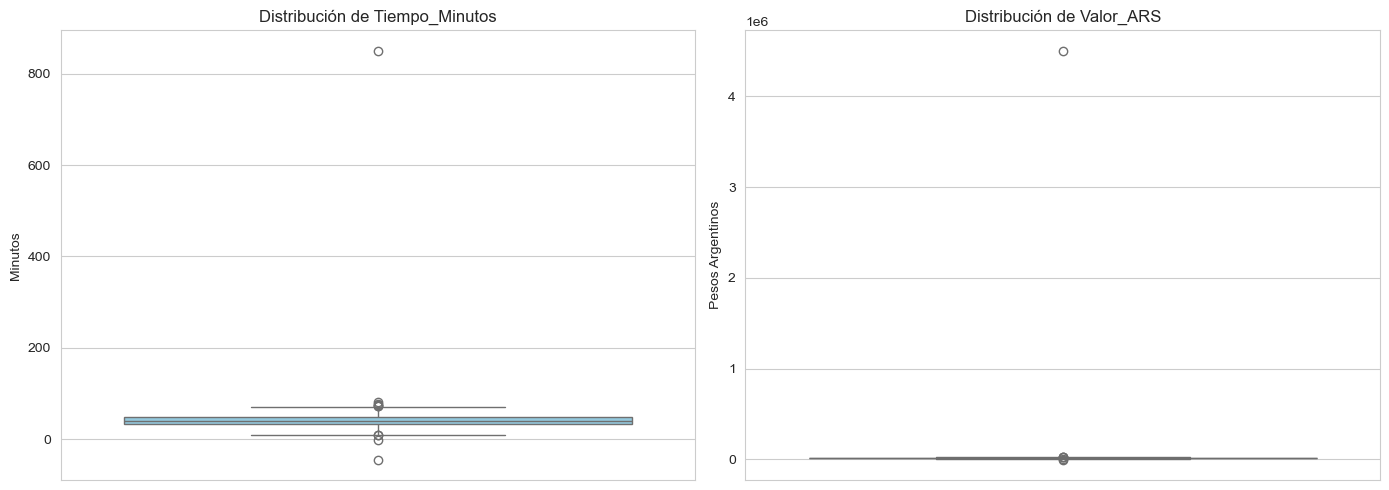

In [3]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
# Boxplot para Tiempo_Minutos
sns.boxplot(y=df['Tiempo_Minutos'], ax=axes[0], color='skyblue')
axes[0].set_title('Distribución de Tiempo_Minutos')
axes[0].set_ylabel('Minutos')

# Boxplot para Valor_ARS
sns.boxplot(y=df['Valor_ARS'], ax=axes[1], color='lightcoral')
axes[1].set_title('Distribución de Valor_ARS')
axes[1].set_ylabel('Pesos Argentinos')

plt.tight_layout()
plt.show()

In [5]:
# Calcular estadísticas descriptivas para fundamentar el informe
print ("""ANÁLISIS DE 'Tiempo_Minutos':
""")
print(df['Tiempo_Minutos'].describe())
print(f"\n• Valores negativos detectados: {(df['Tiempo_Minutos'] < 0).sum()}")
print(f"• Valores extremadamente altos (>120 min): {(df['Tiempo_Minutos'] > 120).sum()}")

print(f"""
ANÁLISIS DE 'Valor_ARS':
""")
print(df['Valor_ARS'].describe())
print(f"\n• Valores nulos (NaN): {df['Valor_ARS'].isnull().sum()}")
print(f"• Valores negativos: {(df['Valor_ARS'] < 0).sum()}")
print(f"• Valores atípicos extremos (>100.000 ARS): {(df['Valor_ARS'] > 100000).sum()}")

print("""
CONCLUSIONES OPERATIVAS:
• Los valores NEGATIVOS en Tiempo_Minutos son ILÓGICOS (no puede haber tiempo negativo).
• El valor de 4,500,000 ARS en Valor_ARS es un ERROR DE SISTEMA (posible fallo en pasarela de pago).
• Los tiempos >120 minutos podrían ser entregas fallidas o datos corruptos del GPS.
• Los valores nulos en Valor_ARS indican fallas en el registro de cobros.

Estos registros deben ser corregidos o eliminados para garantizar la integridad del informe gerencial.
""")

ANÁLISIS DE 'Tiempo_Minutos':

count    820.000000
mean      40.873082
std       30.914142
min      -45.000000
25%       32.297788
50%       39.674302
75%       48.295390
max      850.000000
Name: Tiempo_Minutos, dtype: float64

• Valores negativos detectados: 2
• Valores extremadamente altos (>120 min): 1

ANÁLISIS DE 'Valor_ARS':

count    7.900000e+02
mean     2.089337e+04
std      1.596133e+05
min     -1.500000e+03
25%      1.259845e+04
50%      1.531701e+04
75%      1.794143e+04
max      4.500000e+06
Name: Valor_ARS, dtype: float64

• Valores nulos (NaN): 30
• Valores negativos: 1
• Valores atípicos extremos (>100.000 ARS): 1

CONCLUSIONES OPERATIVAS:
• Los valores NEGATIVOS en Tiempo_Minutos son ILÓGICOS (no puede haber tiempo negativo).
• El valor de 4,500,000 ARS en Valor_ARS es un ERROR DE SISTEMA (posible fallo en pasarela de pago).
• Los tiempos >120 minutos podrían ser entregas fallidas o datos corruptos del GPS.
• Los valores nulos en Valor_ARS indican fallas en el registr

In [6]:
#FASE 2
# Contar duplicados antes de eliminar
duplicados_antes = df.duplicated().sum()
print(f"Registros duplicados encontrados: {duplicados_antes}")

# Eliminar duplicados exactos
df = df.drop_duplicates()

print(f"Duplicados eliminados. Registros restantes: {len(df)}")

Registros duplicados encontrados: 19
Duplicados eliminados. Registros restantes: 801


In [7]:
# Calcular mediana de Valor_ARS (excluyendo NaN)
mediana_valor = df['Valor_ARS'].median()
print(f"Mediana de Valor_ARS para imputación: ${mediana_valor:,.2f}")

# Imputar valores nulos con la mediana
df['Valor_ARS'] = df['Valor_ARS'].fillna(mediana_valor)

# Verificar que no queden nulos
print(f"Valores nulos restantes en 'Valor_ARS': {df['Valor_ARS'].isnull().sum()}")

Mediana de Valor_ARS para imputación: $15,214.25
Valores nulos restantes en 'Valor_ARS': 0


In [8]:
# Calcular Q1, Q3 e IQR para Tiempo_Minutos
Q1 = df['Tiempo_Minutos'].quantile(0.25)
Q3 = df['Tiempo_Minutos'].quantile(0.75)
IQR = Q3 - Q1

print(f"Q1: {Q1:.2f} | Q3: {Q3:.2f} | IQR: {IQR:.2f}")

# Definir límites para outliers
limite_inferior = Q1 - 1.5 * IQR
limite_superior = Q3 + 1.5 * IQR

print(f"Límites aceptables: [{limite_inferior:.2f}, {limite_superior:.2f}]")

# Contar outliers antes de filtrar
outliers = df[(df['Tiempo_Minutos'] < limite_inferior) | (df['Tiempo_Minutos'] > limite_superior)]
print(f"Outliers detectados: {len(outliers)} registros")

# Filtrar y mantener solo valores dentro del rango
df = df[(df['Tiempo_Minutos'] >= limite_inferior) & (df['Tiempo_Minutos'] <= limite_superior)].copy()

print(f"Dataset limpio: {len(df)} registros válidos")

Q1: 32.30 | Q3: 48.38 | IQR: 16.07
Límites aceptables: [8.19, 72.49]
Outliers detectados: 10 registros
Dataset limpio: 791 registros válidos


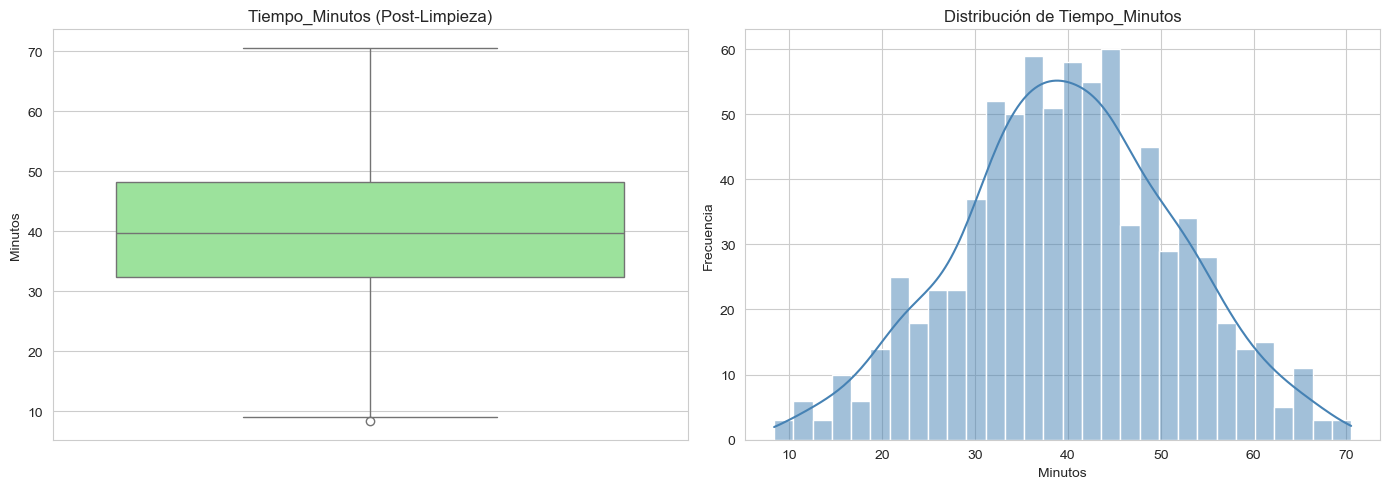

VALIDACIÓN POST-LIMPIEZA:
• Media: 39.96 min
• Mediana: 39.71 min
• Desvío estándar: 11.67 min
• Rango: [8.38, 70.50] min


In [9]:
#FASE 3
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Boxplot post-limpieza
sns.boxplot(y=df['Tiempo_Minutos'], ax=axes[0], color='lightgreen')
axes[0].set_title('Tiempo_Minutos (Post-Limpieza)')
axes[0].set_ylabel('Minutos')

# Histograma con curva de densidad
sns.histplot(df['Tiempo_Minutos'], kde=True, ax=axes[1], color='steelblue', bins=30)
axes[1].set_title('Distribución de Tiempo_Minutos')
axes[1].set_xlabel('Minutos')
axes[1].set_ylabel('Frecuencia')

plt.tight_layout()
plt.show()

# Validación estadística
print(f"VALIDACIÓN POST-LIMPIEZA:")
print(f"• Media: {df['Tiempo_Minutos'].mean():.2f} min")
print(f"• Mediana: {df['Tiempo_Minutos'].median():.2f} min")
print(f"• Desvío estándar: {df['Tiempo_Minutos'].std():.2f} min")
print(f"• Rango: [{df['Tiempo_Minutos'].min():.2f}, {df['Tiempo_Minutos'].max():.2f}] min")

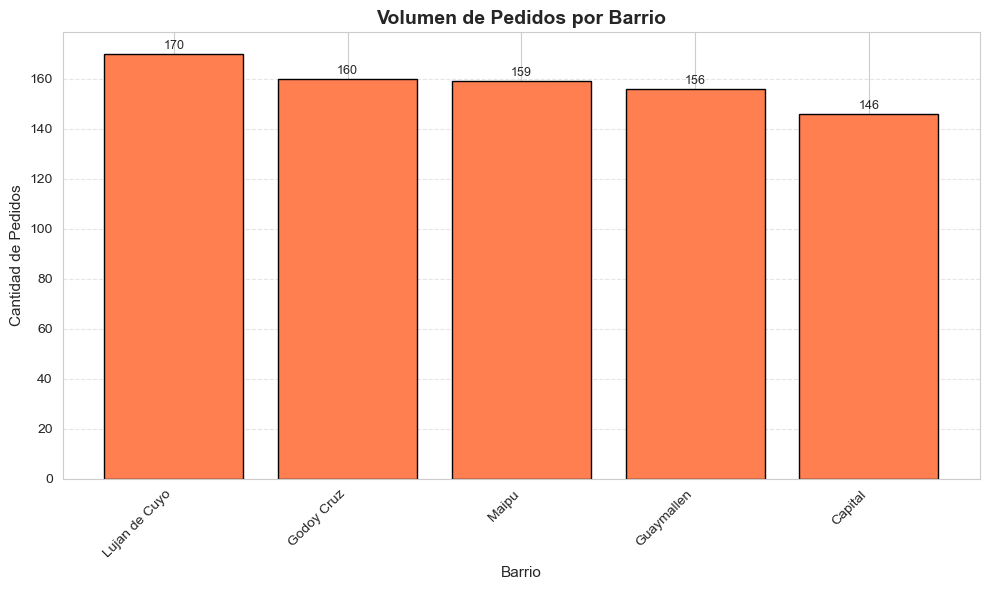


RESUMEN OPERATIVO POR BARRIO:
• Lujan de Cuyo: 170 pedidos
• Godoy Cruz: 160 pedidos
• Maipu: 159 pedidos
• Guaymallen: 156 pedidos
• Capital: 146 pedidos


In [11]:
# Agrupar por Barrio y contar pedidos
pedidos_por_barrio = df['Barrio'].value_counts()

# gráfico de barras 
plt.figure(figsize=(10, 6))
plt.bar(pedidos_por_barrio.index, pedidos_por_barrio.values, color='coral', edgecolor='black')

# Personalización
plt.title('Volumen de Pedidos por Barrio', fontsize=14, fontweight='bold')
plt.xlabel('Barrio', fontsize=11)
plt.ylabel('Cantidad de Pedidos', fontsize=11)
plt.xticks(rotation=45, ha='right')
plt.grid(axis='y', linestyle='--', alpha=0.5)

# Añadir etiquetas de valor en las barras
for i, v in enumerate(pedidos_por_barrio.values):
    plt.text(i, v + 2, str(v), ha='center', fontsize=9)

plt.tight_layout()
plt.show()

# Resumen operativo
print(f"\nRESUMEN OPERATIVO POR BARRIO:")
for barrio, cantidad in pedidos_por_barrio.items():
    print(f"• {barrio}: {cantidad} pedidos")